In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from keras.src.metrics.accuracy_metrics import accuracy

In [2]:
data = pd.read_csv('data.csv')

data.head()

y = data.iloc[:, 0]  # Bankrupt
X = data.iloc[:, 1:]  # All 95 features

print(f"Total companies: {len(data)}")
print(f"Bankruptcies: {y.sum()}")
print(f"Bankruptcy rate: {y.mean():.2%}")

Total companies: 6819
Bankruptcies: 220
Bankruptcy rate: 3.23%


Features shape: (6819, 95)
Top correlations with target:
Bankrupt?                               1.000000
 Debt ratio %                           0.250161
 Current Liability to Assets            0.194494
 Borrowing dependency                   0.176543
 Current Liability to Current Assets    0.171306
 Liability to Equity                    0.166812
 Current Liabilities/Equity             0.153828
 Current Liability to Equity            0.153828
 Liability-Assets Flag                  0.139212
 Total expense/Assets                   0.139049
Name: Bankrupt?, dtype: float64
Strongest negative correlations with target:
Per Share Net profit before tax (Yuan ¥)                  -0.201395
Net profit before tax/Paid-in capital                     -0.207857
Retained Earnings to Total Assets                         -0.217779
Persistent EPS in the Last Four Seasons                   -0.219560
Net worth/Assets                                          -0.250161
ROA(C) before interest and depreciat

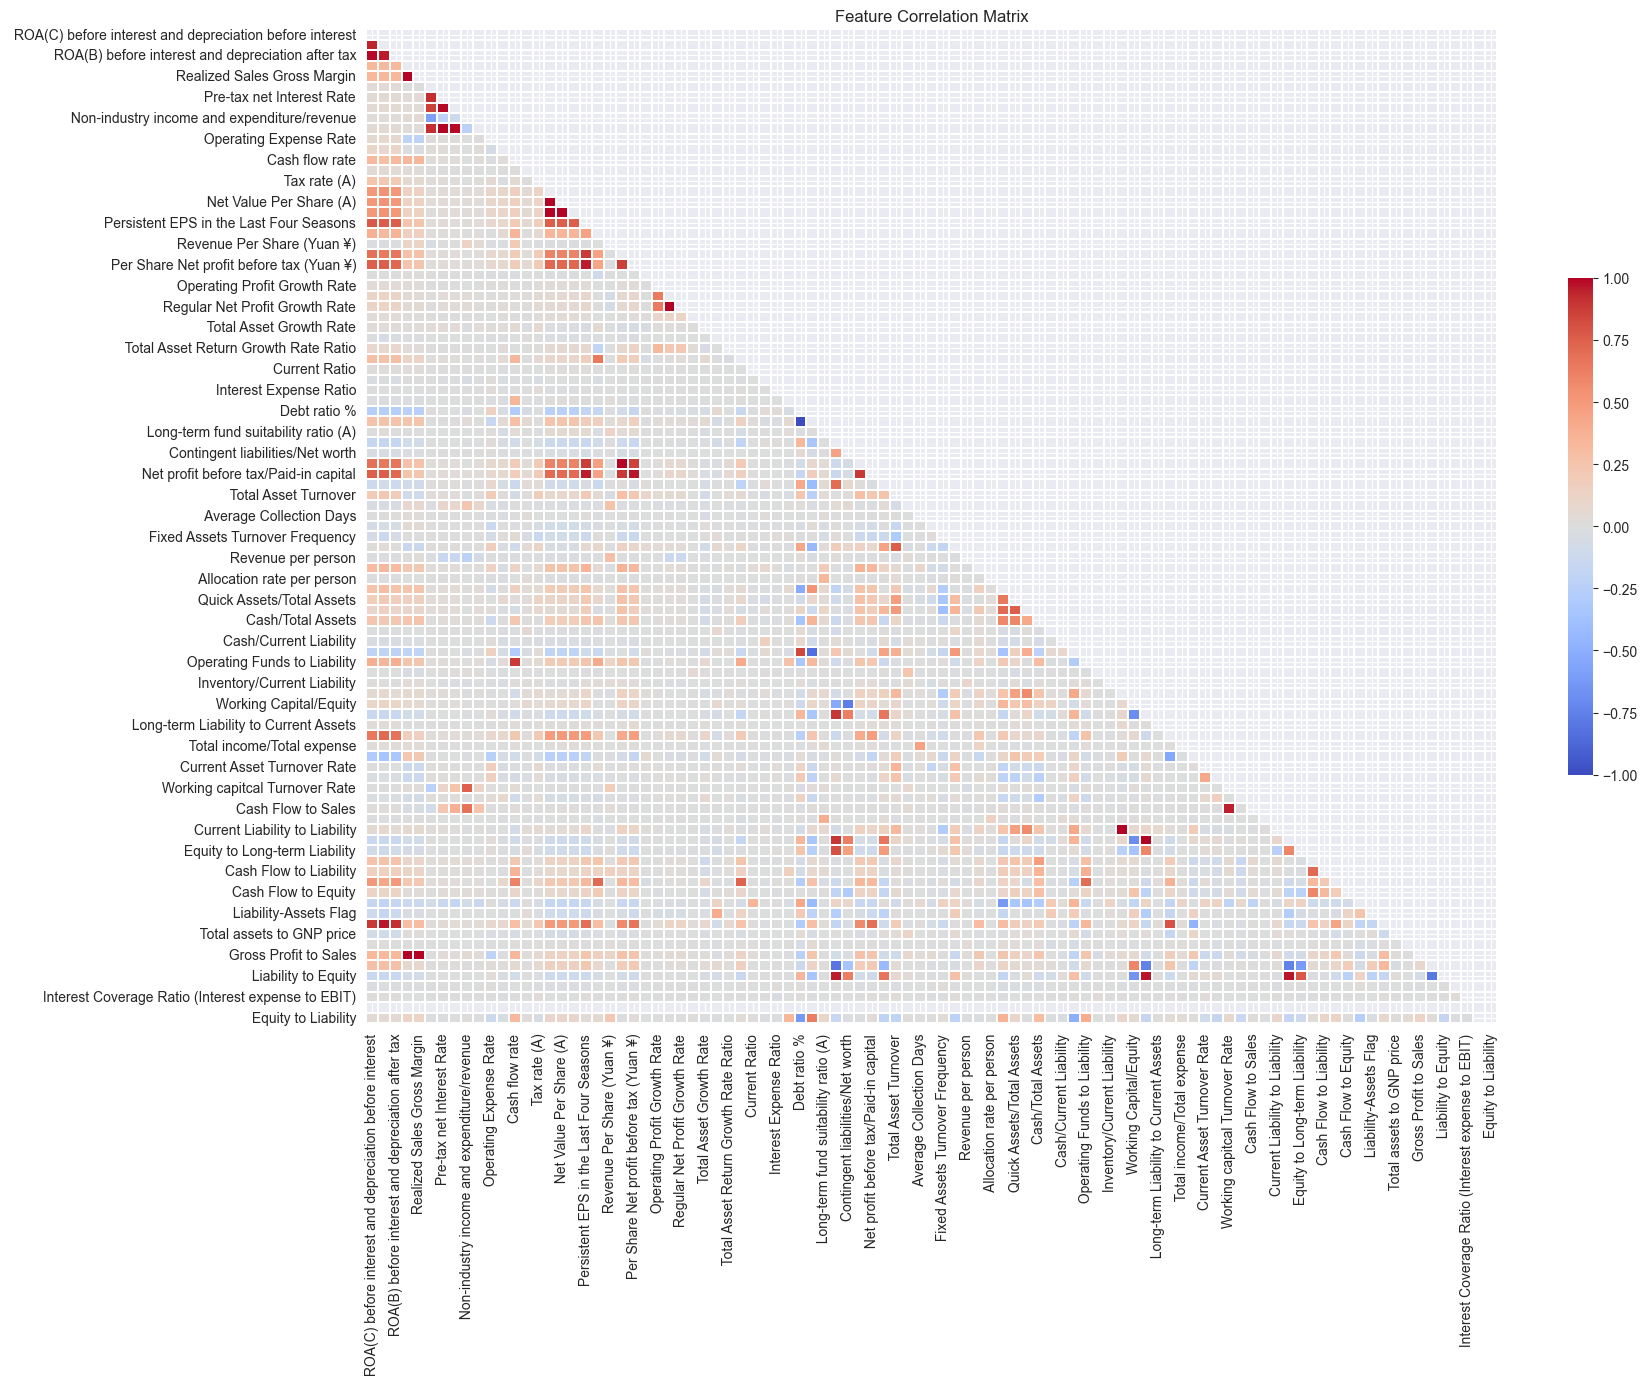

In [3]:
# compute correlations only between features (exclude target column)
target_col = data.columns[0]  # "Bankrupt?"
X_original = data.drop(columns=[target_col])

# feature correlation matrix
corr = X_original.corr()
print(f"Features shape: {X.shape}")

# correlations with the target (for reference)
corr_with_target = data.corr()[target_col].sort_values(ascending=False)
print("Top correlations with target:")
print(corr_with_target.head(10))
print("Strongest negative correlations with target:")
print(corr_with_target.tail(10))

# function returning strongly correlated pairs
def high_corr_pairs(corr_df, thresh=0.8):
    pairs = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack()
    return pairs[abs(pairs) > thresh].sort_values(ascending=False)

thresh = 0.9
strong_pairs = high_corr_pairs(corr, thresh)
print(f"\nFeature pairs with |corr| > {thresh} (count: {len(strong_pairs)}):")
print(strong_pairs)

# function proposing redundant features to drop (deterministic: drop the second feature in each pair)
def get_redundant_features(corr_df, thresh=0.9):
    to_drop = set()
    cols = corr_df.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr_df.iloc[i, j]) > thresh:
                to_drop.add(cols[j])
    return sorted(to_drop)

to_drop = get_redundant_features(corr, thresh)
print(f"\nProposed features to drop (|corr|>{thresh}): {len(to_drop)}")
print(to_drop)


# draw heatmap (mask upper triangle for readability)
plt.figure(figsize=(18,14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.01, cbar_kws={"shrink": .5})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("feature_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Original features: 95
Features after dropping: 76
Reduction: 19 features (20.0%)

Remaining feature pairs with |corr| > 0.9: 0
Success! No remaining pairs above threshold.

Pairs with |corr| > 0.7: 19


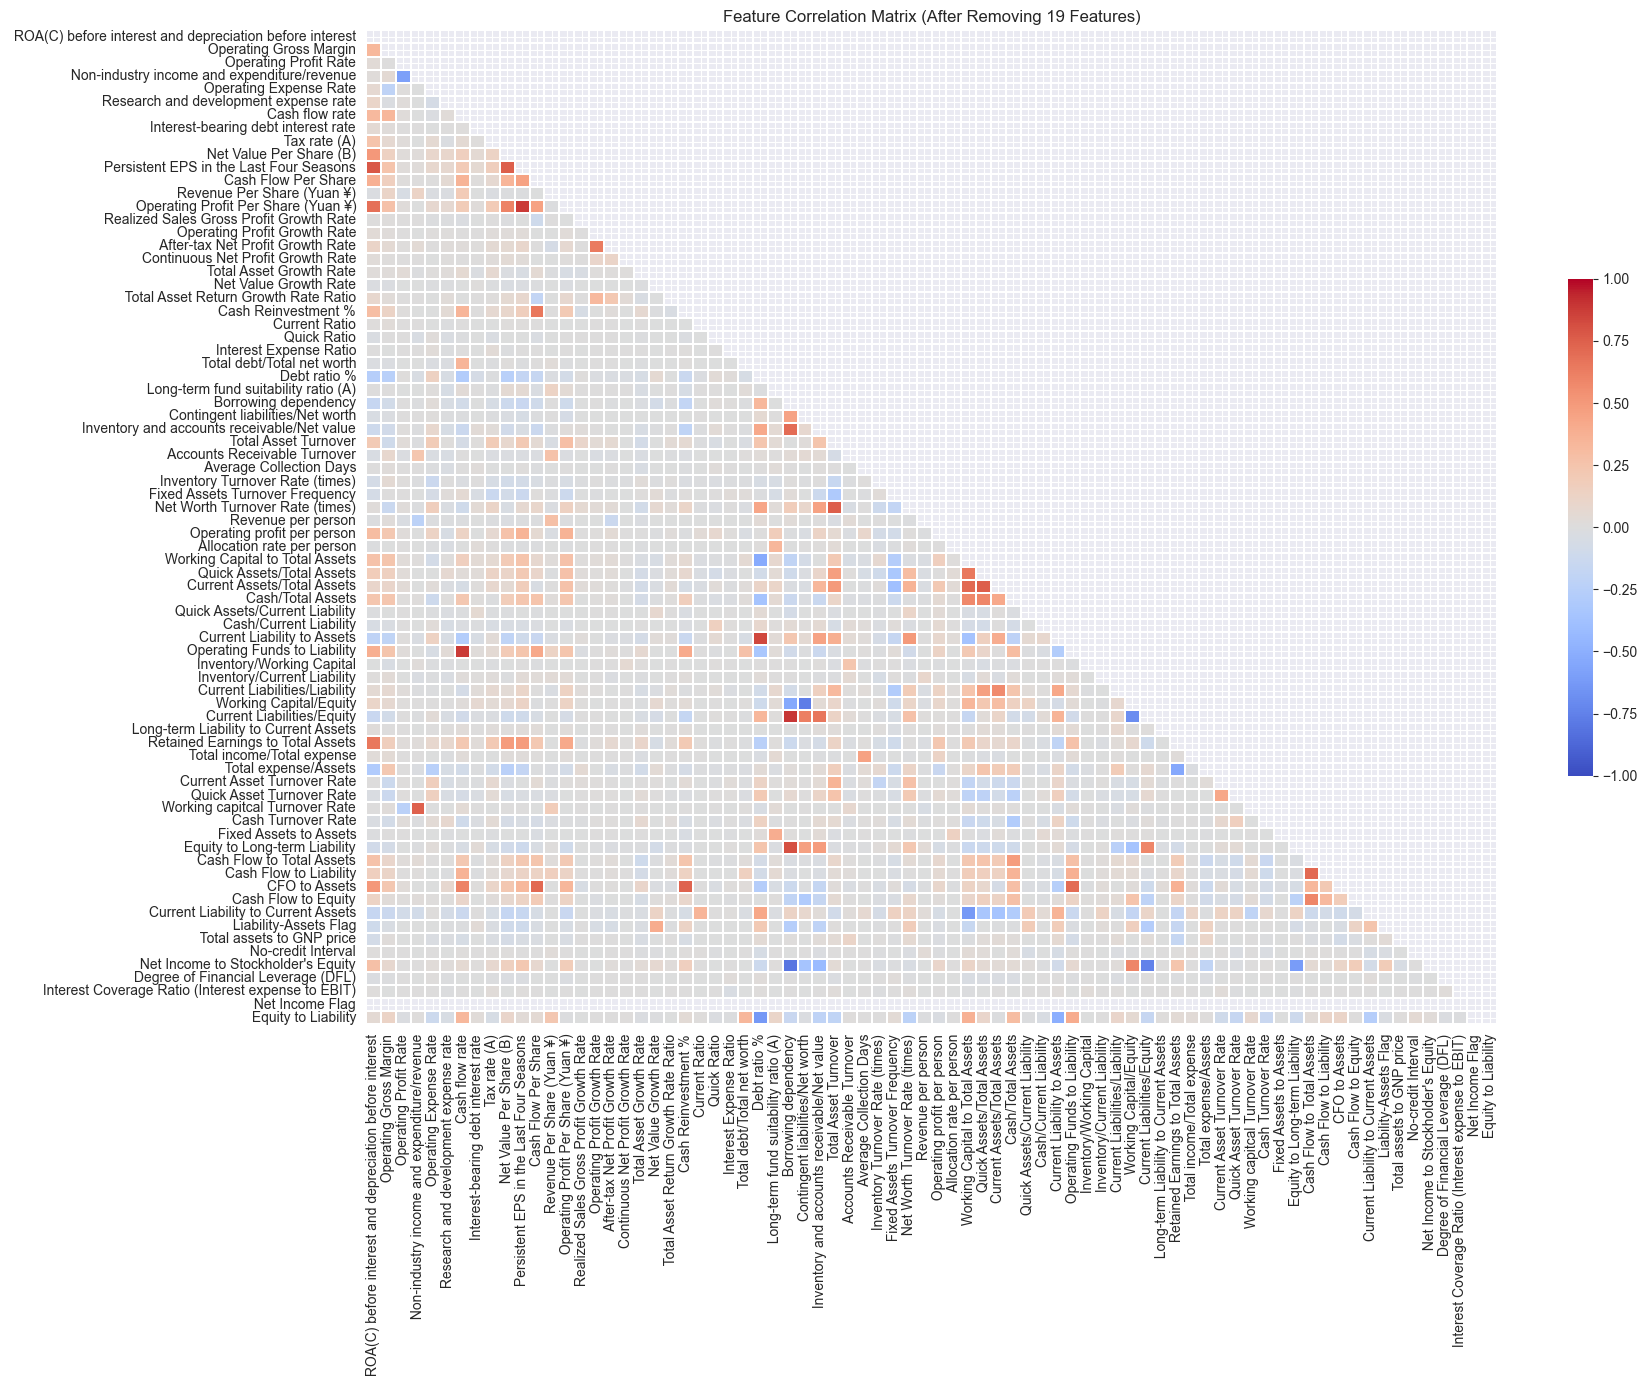

In [4]:
#We want to remove features that are highly correlated to make our model faster i guess
X_clean = X_original.drop(columns=to_drop)
X_clean.head()

print(f"Original features: {X.shape[1]}")
print(f"Features after dropping: {X_clean.shape[1]}")
print(f"Reduction: {X.shape[1] - X_clean.shape[1]} features ({(X.shape[1] - X_clean.shape[1])/X.shape[1]:.1%})")

corr_clean = X_clean.corr()

# check if there are still highly correlated pairs
remaining_pairs = high_corr_pairs(corr_clean, thresh=0.9)
print(f"\nRemaining feature pairs with |corr| > 0.9: {len(remaining_pairs)}")
if len(remaining_pairs) > 0:
    print("Warning: Still have highly correlated pairs!")
    print(remaining_pairs.head(10))
else:
    print("Success! No remaining pairs above threshold.")

lower_thresh_pairs = high_corr_pairs(corr_clean, thresh=0.7)
print(f"\nPairs with |corr| > 0.7: {len(lower_thresh_pairs)}")

plt.figure(figsize=(18,14))
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
sns.heatmap(corr_clean, mask=mask, cmap="coolwarm", center=0, 
            vmin=-1, vmax=1, linewidths=0.01, cbar_kws={"shrink": .5})
plt.title(f"Feature Correlation Matrix (After Removing {len(to_drop)} Features)")
plt.tight_layout()
plt.savefig("feature_correlation_matrix_clean.png", dpi=300, bbox_inches="tight")
plt.show()

## Sci-kit classifier (Baseline)
After cleaning our data, we try the sci-kit classifier to provide a baseline for our research


BASELINE MODEL PERFORMANCE

Strategy: most_frequent
----------------------------------------
  Accuracy:   0.9677
  Precision:  0.0000
  Recall:     0.0000
  F1-Score:   0.0000
  ROC-AUC:    0.5000
  Confusion Matrix: TP=0, FP=0, FN=44, TN=1320

Strategy: stratified
----------------------------------------
  Accuracy:   0.9348
  Precision:  0.0213
  Recall:     0.0227
  F1-Score:   0.0220
  ROC-AUC:    0.4939
  Confusion Matrix: TP=1, FP=46, FN=43, TN=1274

Strategy: uniform
----------------------------------------
  Accuracy:   0.4993
  Precision:  0.0308
  Recall:     0.4773
  F1-Score:   0.0579
  ROC-AUC:    0.5000
  Confusion Matrix: TP=21, FP=660, FN=23, TN=660

Strategy: constant
----------------------------------------
  Accuracy:   0.0323
  Precision:  0.0323
  Recall:     1.0000
  F1-Score:   0.0625
  ROC-AUC:    0.5000
  Confusion Matrix: TP=44, FP=1320, FN=0, TN=0

SUMMARY TABLE
     Strategy  Accuracy  Precision   Recall  F1_Score  ROC_AUC  TP   FP
most_frequent  0.967742 

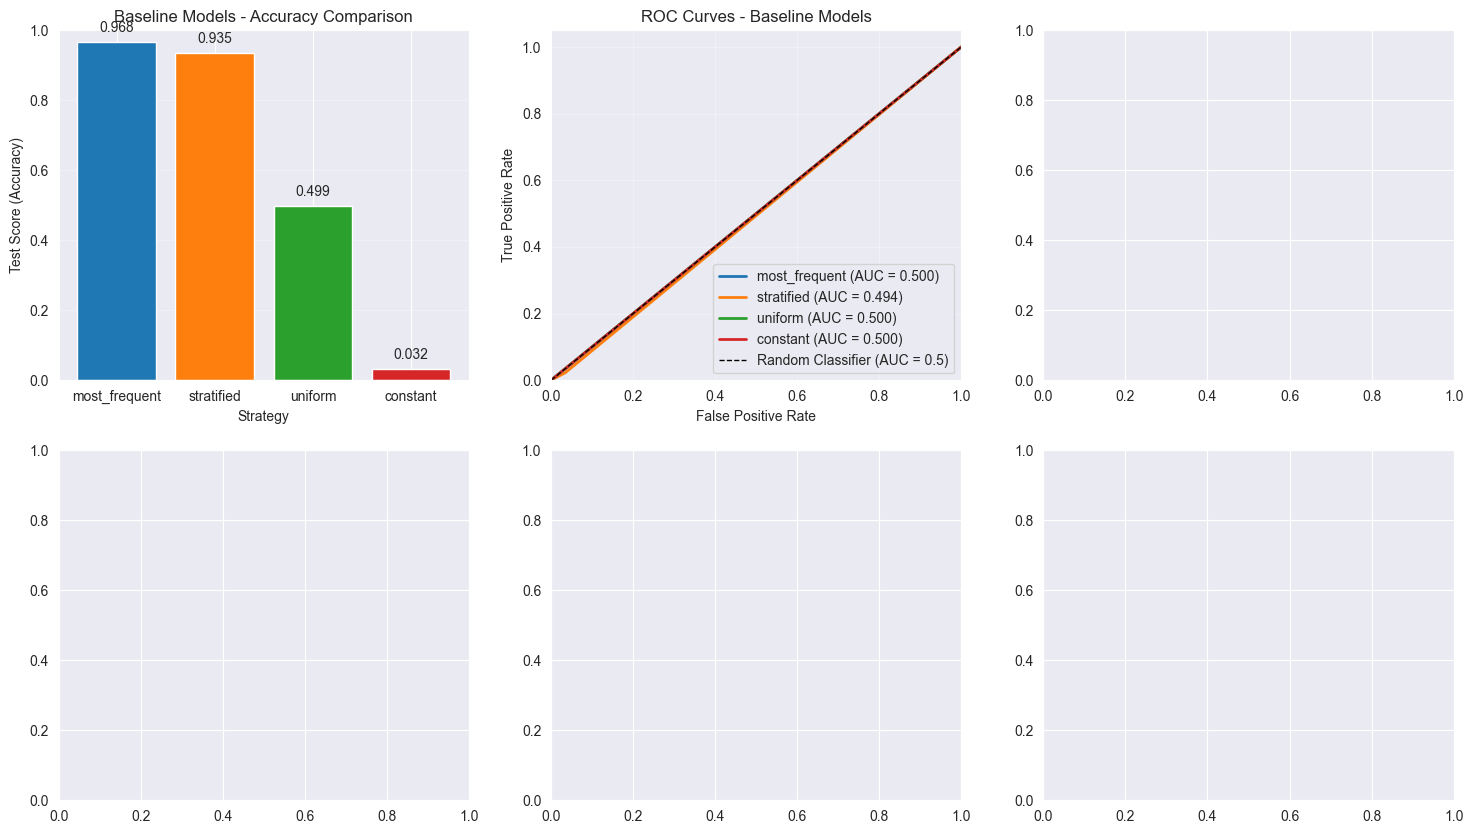

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_auc_score, roc_curve, precision_recall_curve,
                            auc, accuracy_score, f1_score, precision_score,
                            recall_score)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

strategies = ['most_frequent', 'stratified', 'uniform', 'constant']

baseline_results = []
roc_data = {}

print(f"\n" + "=" * 80)
print("BASELINE MODEL PERFORMANCE")
print("=" * 80)

for strategy in strategies:
    print(f"\nStrategy: {strategy}")
    print("-" * 40)

    if strategy == 'constant':
        dclf = DummyClassifier(strategy=strategy, random_state=42, constant=1)
    else:
        dclf = DummyClassifier(strategy=strategy, random_state=42)

    dclf.fit(X_train, y_train)

    y_pred = dclf.predict(X_test)

    if hasattr(dclf, 'predict_proba'):
        y_proba = dclf.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred.astype(float)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    try:
        roc_auc = roc_auc_score(y_test, y_proba)
    except:
        roc_auc = 0.5

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    roc_data[strategy] = {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

    baseline_results.append({
        'Strategy': strategy,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'ROC_AUC': roc_auc,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Description': dclf.strategy
    })

    print(f"  Accuracy:   {accuracy:.4f}")
    print(f"  Precision:  {precision:.4f}")
    print(f"  Recall:     {recall:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  ROC-AUC:    {roc_auc:.4f}")
    print(f"  Confusion Matrix: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

results_df = pd.DataFrame(baseline_results)

print(f"\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
summary_cols = ['Strategy', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'TP', 'FP']
print(results_df[summary_cols].to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Test Scores Bar Plot
ax1 = axes[0, 0]
strategies_names = results_df['Strategy']
test_scores = results_df['Accuracy']
bars = ax1.bar(strategies_names, test_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax1.set_xlabel('Strategy')
ax1.set_ylabel('Test Score (Accuracy)')
ax1.set_title('Baseline Models - Accuracy Comparison')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')

for bar, score in zip(bars, test_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10)

# 2. ROC Curves
ax2 = axes[0, 1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (strategy, data) in enumerate(roc_data.items()):
    ax2.plot(data['fpr'], data['tpr'], color=colors[i], lw=2,
             label=f'{strategy} (AUC = {data["roc_auc"]:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves - Baseline Models')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

print(f"\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for strategy in strategies:
    if strategy == 'constant':
        dclf = DummyClassifier(strategy=strategy, random_state=42, constant=1)
    else:
        dclf = DummyClassifier(strategy=strategy, random_state=42)

    dclf.fit(X_train, y_train)
    y_pred = dclf.predict(X_test)

    print(f"\n{'-' * 60}")
    print(f"Strategy: {strategy}")
    print(f"{'-' * 60}")
    print(classification_report(y_test, y_pred,
                                target_names=['Non-Bankrupt', 'Bankrupt'],
                                digits=4))

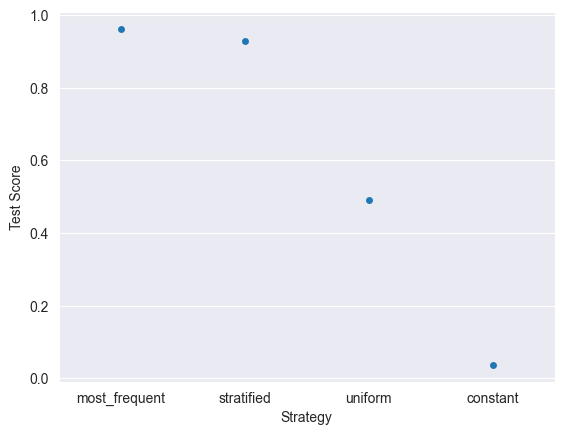

In [6]:
ax = sns.stripplot(x=strategies, y=test_scores)
ax.set(xlabel='Strategy', ylabel='Test Score')
plt.show()

## XGBClassifier

In [7]:
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=29.5,
    max_depth=10,
    learning_rate=0.01,
    n_estimators=200,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy:  0.9545454545454546

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1313
           1       0.42      0.59      0.49        51

    accuracy                           0.95      1364
   macro avg       0.70      0.78      0.73      1364
weighted avg       0.96      0.95      0.96      1364



The classes are seriously imbalanced. We need to implement balancing in order to predict class 1 efficiently


In [8]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, precision_recall_curve

y_prob = model.predict_proba(X_test)
y_prob_bankruptcy = y_prob[:, 1]

print(f"Probability predictions shape: {y_prob_bankruptcy.shape}")
print(f"Sample probabilities (first 10): {y_prob_bankruptcy[:10]}")
print(f"Min probability: {y_prob_bankruptcy.min():.3f}")
print(f"Max probability: {y_prob_bankruptcy.max():.3f}")

thresholds = np.arange(0.05, 1.0, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_bankruptcy > threshold).astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_threshold, average=None)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    results.append({
        "threshold": threshold,
        "precision": precision[1],
        "recall": recall[1],
        "f1": f1[1],
        "support": support,
        "fn": fn,
        "fp": fp,
        "tp": tp,
        "tn": tn,
        "total_predicted_bankrupt": tp + fp
    })

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("THRESHOLD TUNING RESULTS")
print("="*80)
print(results_df.to_string(index=False))

Probability predictions shape: (1364,)
Sample probabilities (first 10): [0.06623627 0.06846865 0.06518374 0.7954227  0.18418057 0.06593294
 0.07364961 0.06521076 0.06518374 0.06518374]
Min probability: 0.064
Max probability: 0.896

THRESHOLD TUNING RESULTS
 threshold  precision   recall       f1    support  fn   fp  tp   tn  total_predicted_bankrupt
      0.05   0.037390 1.000000 0.072085 [1313, 51]   0 1313  51    0                      1364
      0.10   0.144231 0.882353 0.247934 [1313, 51]   6  267  45 1046                       312
      0.15   0.207921 0.823529 0.332016 [1313, 51]   9  160  42 1153                       202
      0.20   0.257862 0.803922 0.390476 [1313, 51]  10  118  41 1195                       159
      0.25   0.295455 0.764706 0.426230 [1313, 51]  12   93  39 1220                       132
      0.30   0.354545 0.764706 0.484472 [1313, 51]  12   71  39 1242                       110
      0.35   0.380000 0.745098 0.503311 [1313, 51]  13   62  38 1251          

C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\galek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

Now we want to find a threshold that gives recall >= 0.8 with best precision

In [9]:
high_recall_results = results_df[results_df['recall'] >= 0.80]
if len(high_recall_results) > 0:
    best_precision_high_recall = high_recall_results.loc[high_recall_results['precision'].idxmax()]
    print("\n" + "="*80)
    print("BEST PRECISION WITH RECALL >= 0.80")
    print("="*80)
    print(f"Threshold: {best_precision_high_recall['threshold']:.2f}")
    print(f"Precision: {best_precision_high_recall['precision']:.3f}")
    print(f"Recall: {best_precision_high_recall['recall']:.3f}")
    print(f"F1-Score: {best_precision_high_recall['f1']:.3f}")
    print(f"Bankruptcies caught: {best_precision_high_recall['tp']:.0f} out of {support[1]}")
    print(f"False alarms: {best_precision_high_recall['fp']:.0f}")
else:
    print("\nNo threshold achieves recall >= 0.80")


BEST PRECISION WITH RECALL >= 0.80
Threshold: 0.20
Precision: 0.258
Recall: 0.804
F1-Score: 0.390
Bankruptcies caught: 41 out of 51
False alarms: 118


Lets try different oversampling methods and compare them

In [10]:
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN,
    BorderlineSMOTE,
    SVMSMOTE
)

from imblearn.combine import (
    SMOTETomek,
    SMOTEENN
)

oversampling_methods = {
    "No oversampling": None,

    "Random OverSampler": RandomOverSampler(
        sampling_strategy='auto',
        random_state=42
    ),

    "SMOTE (current)": SMOTE(
        sampling_strategy='auto',
        k_neighbors=5,
        random_state=42
    ),

    "SMOTE (current)": SMOTE(
        sampling_strategy='auto',
        k_neighbors=3,
        random_state=42
    ),

    "BorderlineSMOTE": BorderlineSMOTE(
        sampling_strategy='auto',
        random_state=42,
        k_neighbors=5,
        m_neighbors=10
    ),

    "ADASYN": ADASYN(
        sampling_strategy='auto',
        n_neighbors=5,
        random_state=42,
    ),

    "SVMSMOTE": SVMSMOTE(
        sampling_strategy='auto',
        k_neighbors=5,
        m_neighbors=10,
        random_state=42
    ),

    "SMOTETomek": SMOTETomek(
        sampling_strategy='auto',
        random_state=42
    ),

    "SMOTEENN": SMOTEENN(
        sampling_strategy='auto',
        random_state=42
    )
}

In [11]:
all_results = []

xgb_params = {
    'scale_pos_weight': 30,
    'max_depth': 3,
    'learning_rate': 0.01,
    'n_estimators': 300,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'eval_metric': 'logloss'
}

X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
print("="*80)
print("TESTING DIFFERENT OVERSAMPLING METHODS")
print("="*80)
print(f"\nOriginal training data distribution:")
print(f"Non-bankrupt: {(y_train == 0).sum()}")
print(f"Bankrupt: {(y_train == 1).sum()}")
print(f"Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")
print("\n")

for method_name, sampler in oversampling_methods.items():
    print(f"\n{'='*80}")
    print(f"Testing {method_name}")
    print(f"\n{'='*80}")

    if sampler is None:
        X_train_res = X_train
        y_train_res = y_train
        print("No oversampling applied (baseline)")
    else:
        try:
            X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)

            print(f"After {method_name}:")
            print(f"  Non-bankrupt: {(y_train_res == 0).sum()}")
            print(f"  Bankrupt: {(y_train_res == 1).sum()}")
            print(f"  Ratio: {(y_train_res == 0).sum() / (y_train_res == 1).sum():.2f}:1")
            print(f"  Total training samples: {len(y_train_res)} (was {len(y_train)})")

        except Exception as e:
            print(f"Error: {e}")
            print(f"Skipping {method_name}")
            continue

    model = XGBClassifier(**xgb_params)
    model.fit(X_train_res, y_train_res, verbose=False)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    result = {
        'Method': method_name,
        'Precision': precision[1],
        'Recall': recall[1],
        'F1': f1[1],
        'FN': fn,
        'FP': fp,
        'TP': tp,
        'TN': tn,
        'Total_actual_bankruptcies': support[1],
        'Bankruptcies_caught': tp,
        'Bankruptcies_missed': fn,
        'False_alarms': fp,
    }

    all_results.append(result)

    print(f"\n  Results on Test Set:")
    print(f"    Precision: {precision[1]:.3f}")
    print(f"    Recall: {recall[1]:.3f}")
    print(f"    F1-Score: {f1[1]:.3f}")
    print(f"    Bankruptcies caught: {tp}/{support[1]} ({tp/support[1]*100:.1f}%)")
    print(f"    False alarms: {fp}")


TESTING DIFFERENT OVERSAMPLING METHODS

Original training data distribution:
Non-bankrupt: 5279
Bankrupt: 176
Ratio: 29.99:1



Testing No oversampling

No oversampling applied (baseline)

  Results on Test Set:
    Precision: 0.223
    Recall: 0.795
    F1-Score: 0.348
    Bankruptcies caught: 35/44 (79.5%)
    False alarms: 122

Testing Random OverSampler

After Random OverSampler:
  Non-bankrupt: 5279
  Bankrupt: 5279
  Ratio: 1.00:1
  Total training samples: 10558 (was 5455)

  Results on Test Set:
    Precision: 0.110
    Recall: 0.955
    F1-Score: 0.198
    Bankruptcies caught: 42/44 (95.5%)
    False alarms: 339

Testing SMOTE (current)

After SMOTE (current):
  Non-bankrupt: 5279
  Bankrupt: 5279
  Ratio: 1.00:1
  Total training samples: 10558 (was 5455)

  Results on Test Set:
    Precision: 0.100
    Recall: 0.955
    F1-Score: 0.181
    Bankruptcies caught: 42/44 (95.5%)
    False alarms: 378

Testing BorderlineSMOTE

After BorderlineSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 

The 1:1 ratio in oversampling is too agressive and unrealistic, so we try different intermediate ratios:

In [13]:
from imblearn.over_sampling import SVMSMOTE

sampling_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
ratio_results = []

for ratio in sampling_ratios:
    print(f"\n{'=' * 60}")
    print(f"Testing sampling ratio: {ratio} (1:{1 / ratio:.1f})")
    print(f"{'=' * 60}")

    smote = SVMSMOTE(
        sampling_strategy='auto',
        k_neighbors=5,
        m_neighbors=10,
        random_state=42
    )
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    print(f"After SVMSMOTE:")
    print(f"  Non-bankrupt: {(y_train_res == 0).sum()}")
    print(f"  Bankrupt: {(y_train_res == 1).sum()}")

    model = XGBClassifier(**xgb_params)
    model.fit(X_train_res, y_train_res, verbose=False)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, average=None
    )
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    ratio_results.append({
        'Sampling_Ratio': ratio,
        'Target_Balance': f"1:{1 / ratio:.1f}",
        'Precision': precision[1],
        'Recall': recall[1],
        'F1': f1[1],
        'TP': tp,
        'FP': fp,
        'FN': fn
    })

    print(f"  Precision: {precision[1]:.3f}")
    print(f"  Recall: {recall[1]:.3f}")
    print(f"  F1-Score: {f1[1]:.3f}")

ratio_df = pd.DataFrame(ratio_results)
print("\n" + "=" * 80)
print("SUMMARY: Impact of Sampling Ratio")
print("=" * 80)
print(ratio_df.to_string(index=False))


Testing sampling ratio: 0.1 (1:10.0)
After SVMSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 2982
  Precision: 0.141
  Recall: 0.932
  F1-Score: 0.245

Testing sampling ratio: 0.2 (1:5.0)
After SVMSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 2982
  Precision: 0.141
  Recall: 0.932
  F1-Score: 0.245

Testing sampling ratio: 0.3 (1:3.3)
After SVMSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 2982
  Precision: 0.141
  Recall: 0.932
  F1-Score: 0.245

Testing sampling ratio: 0.4 (1:2.5)
After SVMSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 2982
  Precision: 0.141
  Recall: 0.932
  F1-Score: 0.245

Testing sampling ratio: 0.5 (1:2.0)
After SVMSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 2982
  Precision: 0.141
  Recall: 0.932
  F1-Score: 0.245

Testing sampling ratio: 1.0 (1:1.0)
After SVMSMOTE:
  Non-bankrupt: 5279
  Bankrupt: 2982
  Precision: 0.141
  Recall: 0.932
  F1-Score: 0.245

SUMMARY: Impact of Sampling Ratio
 Sampling_Ratio Target_Balance  Precision   Recall       F1  TP  FP  FN
            0.1         1:10

## XGBOOST + SVMSMOTE RESULTS

XGBOOST + SVMSMOTE WITH OPTIMAL THRESHOLD TUNING

Original Training Data:
Non-bankrupt: 5,279 (96.8%)
Bankrupt: 176 (3.2%)
Imbalance Ratio: 30.0:1

After SVMSMOTE Oversampling:
Non-bankrupt: 5,279
Bankrupt: 2,982
Balance Ratio: 1.8:1

Training XGBoost with 8,261 samples...

THRESHOLD OPTIMIZATION RESULTS

1. Optimal Threshold (Max F1-score):
   Threshold: 0.980
   F1-score: 0.516
   Precision: 0.490
   Recall: 0.545

2. Business-Oriented Threshold (Recall ≥ 0.80):
   Threshold: 0.910
   F1-score: 0.407
   Precision: 0.271
   Recall: 0.818

FINAL RESULTS AT THRESHOLD = 0.910

Confusion Matrix:
               Predicted 0    Predicted 1
Actual 0:      TN= 1223       FP=   97
Actual 1:      FN=    8       TP=   36

Classification Metrics (Class 1 - Bankruptcy):
  Accuracy:    0.923
  Precision:   0.271 (Positive Predictive Value)
  Recall:      0.818 (Sensitivity, True Positive Rate)
  F1-Score:    0.407
  Specificity: 0.927 (True Negative Rate)
  NPV:         0.994 (Negative Predictive Va

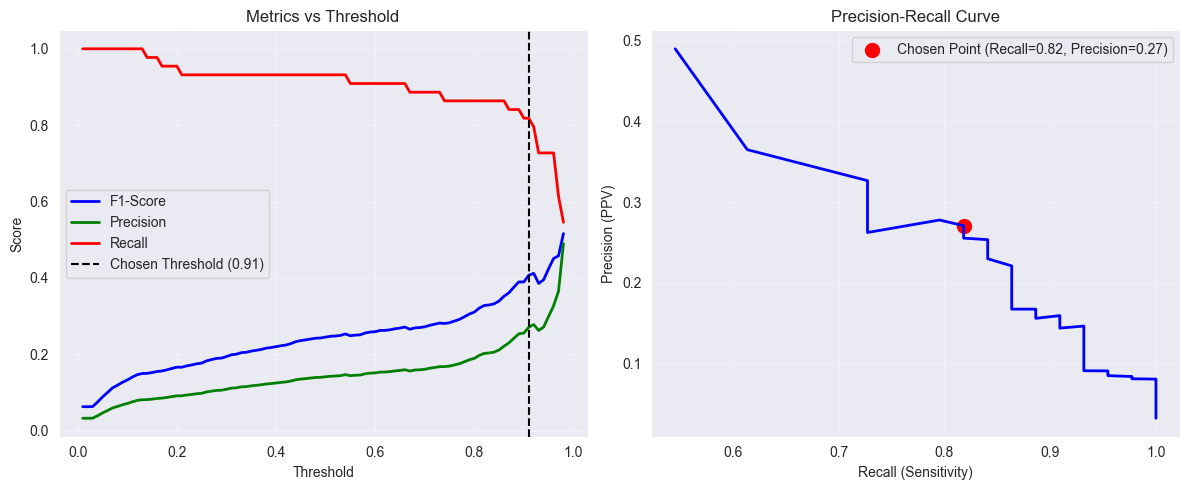


MODEL SUMMARY
Model: XGBoost with 300 trees
Oversampler: SVMSMOTE (k=5, m=10)
Optimal threshold selected: 0.910
Key achievement: 81.8% recall with 27.1% precision


In [14]:
from imblearn.over_sampling import SVMSMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                            precision_recall_fscore_support, roc_auc_score,
                            precision_recall_curve, auc, f1_score)

xgb_params = {
    'scale_pos_weight': 30,
    'max_depth': 3,
    'learning_rate': 0.01,
    'n_estimators': 300,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'eval_metric': 'logloss'
}

svmsmote_sampler = SVMSMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    m_neighbors=10,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 80)
print("XGBOOST + SVMSMOTE WITH OPTIMAL THRESHOLD TUNING")
print("=" * 80)

print(f"\nOriginal Training Data:")
print(f"Non-bankrupt: {(y_train == 0).sum():,} ({100*(y_train == 0).mean():.1f}%)")
print(f"Bankrupt: {(y_train == 1).sum():,} ({100*(y_train == 1).mean():.1f}%)")
print(f"Imbalance Ratio: {(y_train == 0).sum()/(y_train == 1).sum():.1f}:1")

X_train_res, y_train_res = svmsmote_sampler.fit_resample(X_train, y_train)
print(f"\nAfter SVMSMOTE Oversampling:")
print(f"Non-bankrupt: {(y_train_res == 0).sum():,}")
print(f"Bankrupt: {(y_train_res == 1).sum():,}")
print(f"Balance Ratio: {(y_train_res == 0).sum()/(y_train_res == 1).sum():.1f}:1")

print(f"\nTraining XGBoost with {len(X_train_res):,} samples...")
model = XGBClassifier(**xgb_params)
model.fit(X_train_res, y_train_res, verbose=False)

y_prob = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores = []
precisions = []
recalls = []

for threshold in thresholds:
    y_pred_threshold = (y_prob > threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_threshold, average='binary'
    )
    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)


optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]

high_recall_mask = np.array(recalls) >= 0.80
if high_recall_mask.any():
    high_recall_indices = np.where(high_recall_mask)[0]
    best_high_recall_idx = high_recall_indices[np.argmax(np.array(precisions)[high_recall_mask])]
    business_threshold = thresholds[best_high_recall_idx]
    business_precision = precisions[best_high_recall_idx]
    business_recall = recalls[best_high_recall_idx]
    business_f1 = f1_scores[best_high_recall_idx]
else:
    business_threshold = optimal_threshold
    business_precision = optimal_precision
    business_recall = optimal_recall
    business_f1 = optimal_f1

print("\n" + "=" * 80)
print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 80)

print(f"\n1. Optimal Threshold (Max F1-score):")
print(f"   Threshold: {optimal_threshold:.3f}")
print(f"   F1-score: {optimal_f1:.3f}")
print(f"   Precision: {optimal_precision:.3f}")
print(f"   Recall: {optimal_recall:.3f}")

print(f"\n2. Business-Oriented Threshold (Recall ≥ 0.80):")
print(f"   Threshold: {business_threshold:.3f}")
print(f"   F1-score: {business_f1:.3f}")
print(f"   Precision: {business_precision:.3f}")
print(f"   Recall: {business_recall:.3f}")

final_threshold = business_threshold
y_pred_final = (y_prob > final_threshold).astype(int)

print(f"\n" + "=" * 80)
print(f"FINAL RESULTS AT THRESHOLD = {final_threshold:.3f}")
print("=" * 80)

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_final, average=None
)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
roc_auc = roc_auc_score(y_test, y_prob)


accuracy = (tp + tn) / (tp + tn + fp + fn)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\nConfusion Matrix:")
print(f"               Predicted 0    Predicted 1")
print(f"Actual 0:      TN={tn:5d}       FP={fp:5d}")
print(f"Actual 1:      FN={fn:5d}       TP={tp:5d}")

print(f"\nClassification Metrics (Class 1 - Bankruptcy):")
print(f"  Accuracy:    {accuracy:.3f}")
print(f"  Precision:   {precision[1]:.3f} (Positive Predictive Value)")
print(f"  Recall:      {recall[1]:.3f} (Sensitivity, True Positive Rate)")
print(f"  F1-Score:    {f1[1]:.3f}")
print(f"  Specificity: {specificity:.3f} (True Negative Rate)")
print(f"  NPV:         {npv:.3f} (Negative Predictive Value)")
print(f"  ROC-AUC:     {roc_auc:.3f}")

print(f"\nBankruptcy Detection Performance:")
print(f"  Total bankruptcies in test set: {support[1]:,}")
print(f"  Bankruptcies correctly caught:  {tp:,} ({100*tp/support[1]:.1f}%)")
print(f"  Bankruptcies missed:            {fn:,} ({100*fn/support[1]:.1f}%)")
print(f"  False alarms:                   {fp:,} (non-bankrupt flagged)")

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_curve, precision_curve)
print(f"  PR-AUC:       {pr_auc:.3f} (Precision-Recall AUC)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Non-Bankrupt', 'Bankrupt']))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, 'b-', label='F1-Score', linewidth=2)
plt.plot(thresholds, precisions, 'g-', label='Precision', linewidth=2)
plt.plot(thresholds, recalls, 'r-', label='Recall', linewidth=2)
plt.axvline(x=final_threshold, color='k', linestyle='--', label=f'Chosen Threshold ({final_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, 'b-', linewidth=2)
plt.scatter([business_recall], [business_precision], color='red', s=100,
           label=f'Chosen Point (Recall={business_recall:.2f}, Precision={business_precision:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n" + "=" * 80)
print("MODEL SUMMARY")
print("=" * 80)
print(f"Model: XGBoost with {xgb_params['n_estimators']} trees")
print(f"Oversampler: SVMSMOTE (k=5, m=10)")
print(f"Optimal threshold selected: {final_threshold:.3f}")
print(f"Key achievement: {business_recall*100:.1f}% recall with {business_precision*100:.1f}% precision")

In [15]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (classification_report, confusion_matrix,
                            precision_recall_fscore_support, roc_auc_score,
                            precision_recall_curve, auc, roc_curve,
                            accuracy_score, f1_score)

rf_params = {
    'n_estimators': 200,
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced_subsample',
    'random_state': 42,
    'n_jobs': -1,
    'bootstrap': True,
    'oob_score': True,
    'max_samples': 0.8
}

svmsmote_sampler = SVMSMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    m_neighbors=10,
    random_state=42,
    svm_estimator=None
)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train_res, y_train_res)

y_prob = rf_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.01, 0.99, 0.01)
results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob > threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_threshold, average='binary'
    )
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'npv': npv,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    })

results_df = pd.DataFrame(results)

optimal_f1_idx = results_df['f1'].idxmax()
optimal_f1_threshold = results_df.loc[optimal_f1_idx, 'threshold']

high_recall_mask = results_df['recall'] >= 0.80
if high_recall_mask.any():
    high_recall_results = results_df[high_recall_mask]
    business_idx = high_recall_results['precision'].idxmax()
    business_threshold = results_df.loc[business_idx, 'threshold']
else:
    business_idx = results_df['recall'].idxmax()
    business_threshold = results_df.loc[business_idx, 'threshold']

print(f"\nTHRESHOLD SELECTION RESULTS:")
print(f"1. Optimal F1 Threshold: {optimal_f1_threshold:.3f}")
print(f"   F1-score: {results_df.loc[optimal_f1_idx, 'f1']:.3f}")
print(f"   Precision: {results_df.loc[optimal_f1_idx, 'precision']:.3f}")
print(f"   Recall: {results_df.loc[optimal_f1_idx, 'recall']:.3f}")

print(f"\n2. Business-Oriented Threshold (Prioritizing Recall ≥ 0.80): {business_threshold:.3f}")
print(f"   F1-score: {results_df.loc[business_idx, 'f1']:.3f}")
print(f"   Precision: {results_df.loc[business_idx, 'precision']:.3f}")
print(f"   Recall: {results_df.loc[business_idx, 'recall']:.3f}")

final_threshold = business_threshold
y_pred_final = (y_prob > final_threshold).astype(int)

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_final, average=None
)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
roc_auc = roc_auc_score(y_test, y_prob)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall_curve, precision_curve)


print(f"\n" + "=" * 80)
print(f"FINAL RESULTS AT THRESHOLD = {final_threshold:.3f}")
print("=" * 80)

print(f"\nCONFUSION MATRIX:")
print(f"{'':<20} {'Predicted 0':<15} {'Predicted 1':<15}")
print(f"{'Actual 0 (Non-bankrupt)':<20} {tn:<15} {fp:<15}")
print(f"{'Actual 1 (Bankrupt)':<20} {fn:<15} {tp:<15}")

print(f"\nDETAILED METRICS:")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision (PPV):    {precision[1]:.4f}  (Positive Predictive Value)")
print(f"Recall (Sensitivity): {recall[1]:.4f}  (True Positive Rate)")
print(f"Specificity:        {specificity:.4f}  (True Negative Rate)")
print(f"F1-Score:           {f1[1]:.4f}")
print(f"NPV:                {npv:.4f}  (Negative Predictive Value)")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:             {pr_auc:.4f}  (Precision-Recall AUC)")

print(f"\nBANKRUPTCY DETECTION PERFORMANCE:")
print(f"Total bankruptcies in test set:   {support[1]:,}")
print(f"Bankruptcies correctly caught:    {tp:,} ({100*tp/support[1]:.1f}%)")
print(f"Bankruptcies missed:              {fn:,} ({100*fn/support[1]:.1f}%)")
print(f"False alarms (Type I errors):     {fp:,}")



THRESHOLD SELECTION RESULTS:
1. Optimal F1 Threshold: 0.560
   F1-score: 0.511
   Precision: 0.480
   Recall: 0.545

2. Business-Oriented Threshold (Prioritizing Recall ≥ 0.80): 0.200
   F1-score: 0.351
   Precision: 0.224
   Recall: 0.818

FINAL RESULTS AT THRESHOLD = 0.200

CONFUSION MATRIX:
                     Predicted 0     Predicted 1    
Actual 0 (Non-bankrupt) 1195            125            
Actual 1 (Bankrupt)  8               36             

DETAILED METRICS:
Accuracy:           0.9025
Precision (PPV):    0.2236  (Positive Predictive Value)
Recall (Sensitivity): 0.8182  (True Positive Rate)
Specificity:        0.9053  (True Negative Rate)
F1-Score:           0.3512
NPV:                0.9933  (Negative Predictive Value)
ROC-AUC:            0.9489
PR-AUC:             0.4860  (Precision-Recall AUC)

BANKRUPTCY DETECTION PERFORMANCE:
Total bankruptcies in test set:   44
Bankruptcies correctly caught:    36 (81.8%)
Bankruptcies missed:              8 (18.2%)
False alarms (Type

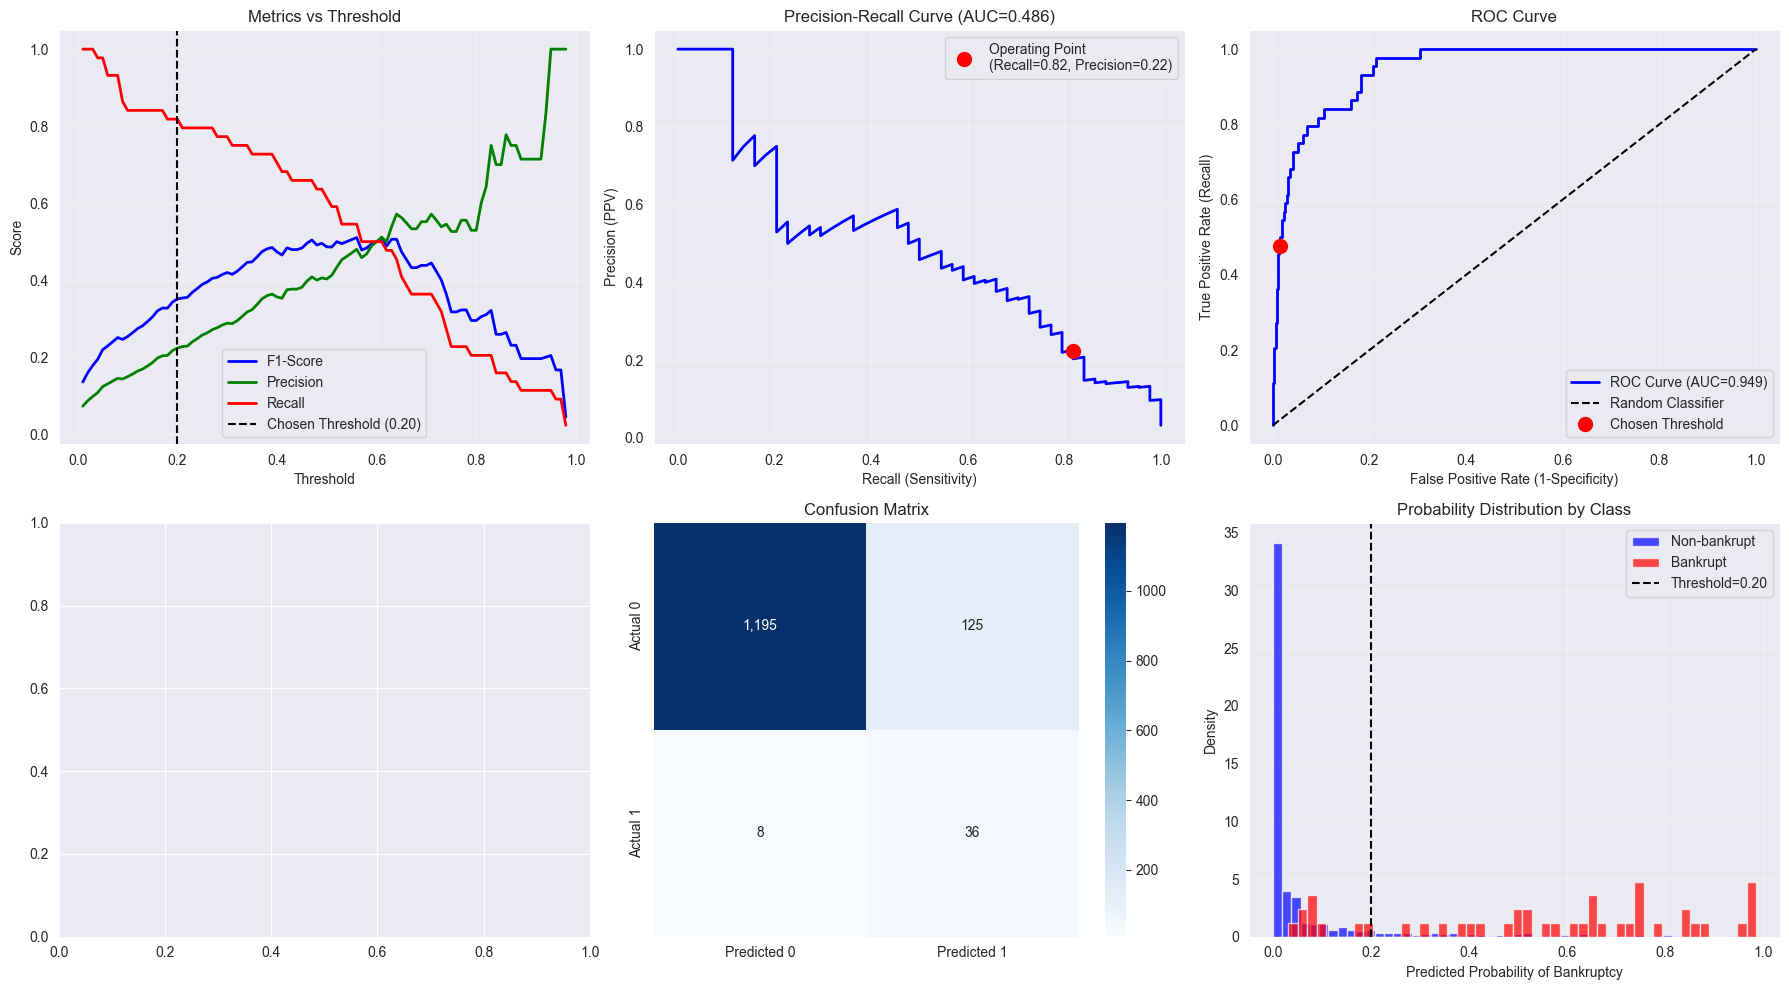

              precision    recall  f1-score   support

Non-Bankrupt     0.9933    0.9053    0.9473      1320
    Bankrupt     0.2236    0.8182    0.3512        44

    accuracy                         0.9025      1364
   macro avg     0.6085    0.8617    0.6493      1364
weighted avg     0.9685    0.9025    0.9281      1364



In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Threshold vs Metrics
ax1 = axes[0, 0]
ax1.plot(results_df['threshold'], results_df['f1'], 'b-', label='F1-Score', linewidth=2)
ax1.plot(results_df['threshold'], results_df['precision'], 'g-', label='Precision', linewidth=2)
ax1.plot(results_df['threshold'], results_df['recall'], 'r-', label='Recall', linewidth=2)
ax1.axvline(x=final_threshold, color='k', linestyle='--',
           label=f'Chosen Threshold ({final_threshold:.2f})')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Metrics vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Precision-Recall Curve
ax2 = axes[0, 1]
ax2.plot(recall_curve, precision_curve, 'b-', linewidth=2)
ax2.plot([recall[1]], [precision[1]], 'ro', markersize=10,
        label=f'Operating Point\n(Recall={recall[1]:.2f}, Precision={precision[1]:.2f})')
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision (PPV)')
ax2.set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. ROC Curve
ax3 = axes[0, 2]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax3.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC={roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax3.plot([fpr[np.where(results_df['threshold'] >= final_threshold)[0][0]]],
         [tpr[np.where(results_df['threshold'] >= final_threshold)[0][0]]],
         'ro', markersize=10, label='Chosen Threshold')
ax3.set_xlabel('False Positive Rate (1-Specificity)')
ax3.set_ylabel('True Positive Rate (Recall)')
ax3.set_title('ROC Curve')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrix Heatmap
ax4 = axes[1, 1]
conf_matrix = np.array([[tn, fp], [fn, tp]])
sns.heatmap(conf_matrix, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=ax4)
ax4.set_title('Confusion Matrix')

# 5. Probability Distribution
ax6 = axes[1, 2]
ax6.hist(y_prob[y_test == 0], bins=50, alpha=0.7, label='Non-bankrupt', color='blue', density=True)
ax6.hist(y_prob[y_test == 1], bins=50, alpha=0.7, label='Bankrupt', color='red', density=True)
ax6.axvline(x=final_threshold, color='k', linestyle='--', label=f'Threshold={final_threshold:.2f}')
ax6.set_xlabel('Predicted Probability of Bankruptcy')
ax6.set_ylabel('Density')
ax6.set_title('Probability Distribution by Class')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(classification_report(y_test, y_pred_final, target_names=['Non-Bankrupt', 'Bankrupt'], digits=4))

MULTI-MODEL COMPARISON WITH SVMSMOTE OVERSAMPLING

DATA OVERVIEW:
Training samples: 5,455
Test samples: 1,364
Bankruptcy rate: 3.23%
Training - Class 0: 5,279 (96.8%)
Training - Class 1: 176 (3.2%)

APPLYING SVMSMOTE OVERSAMPLING...
After oversampling - Class 0: 5,279
After oversampling - Class 1: 2,982

TRAINING ALL MODELS

──────────────────────────────────────────────────
Training XGBoost...
Parameters: {'scale_pos_weight': 30, 'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 300, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'random_state': 42, 'eval_metric': 'logloss', 'n_jobs': -1}
✓ XGBoost trained successfully

──────────────────────────────────────────────────
Training Random Forest...
Parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample', 'random_state': 42, 'n_jobs': -1, 'bootstrap': True, 'oob_

TypeError: 'dict_keys' object is not subscriptable

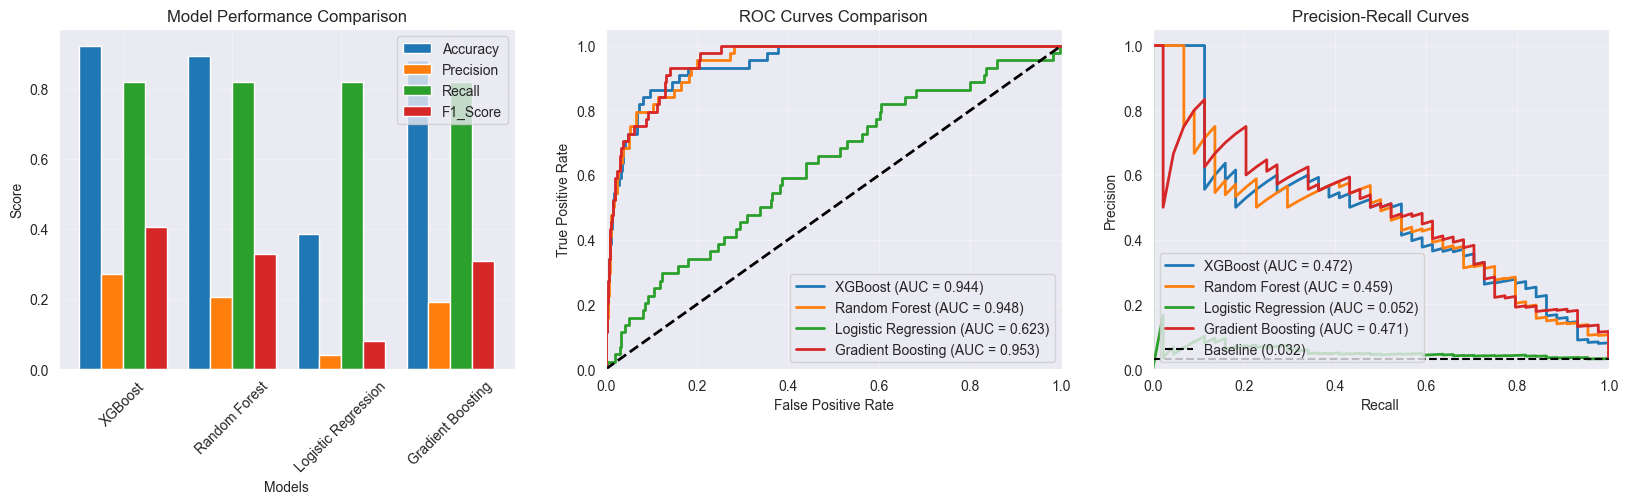

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SVMSMOTE
from sklearn.metrics import (classification_report, confusion_matrix,
                            precision_recall_fscore_support, roc_auc_score,
                            precision_recall_curve, auc, roc_curve,
                            accuracy_score, f1_score)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

print("=" * 100)
print("MULTI-MODEL COMPARISON WITH SVMSMOTE OVERSAMPLING")
print("=" * 100)

models_config = {
    'XGBoost': {
        'class': XGBClassifier,
        'params': {
            'scale_pos_weight': 30,
            'max_depth': 3,
            'learning_rate': 0.01,
            'n_estimators': 300,
            'min_child_weight': 10,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 0.1,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'random_state': 42,
            'eval_metric': 'logloss',
            'n_jobs': -1
        }
    },
    'Random Forest': {
        'class': RandomForestClassifier,
        'params': {
            'n_estimators': 200,
            'max_depth': 15,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'sqrt',
            'class_weight': 'balanced_subsample',
            'random_state': 42,
            'n_jobs': -1,
            'bootstrap': True,
            'oob_score': True
        }
    },
    'Logistic Regression': {
        'class': LogisticRegression,
        'params': {
            'C': 0.1,
            'penalty': 'l2',
            'solver': 'liblinear',
            'class_weight': 'balanced',
            'random_state': 42,
            'max_iter': 1000
        }
    },
    'Gradient Boosting': {
        'class': GradientBoostingClassifier,
        'params': {
            'n_estimators': 200,
            'learning_rate': 0.05,
            'max_depth': 4,
            'min_samples_split': 10,
            'min_samples_leaf': 4,
            'subsample': 0.8,
            'random_state': 42,
            'max_features': 'sqrt'
        }
    }
}

svmsmote_sampler = SVMSMOTE(
    sampling_strategy='auto',
    k_neighbors=5,
    m_neighbors=10,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDATA OVERVIEW:")
print(f"Training samples: {len(y_train):,}")
print(f"Test samples: {len(y_test):,}")
print(f"Bankruptcy rate: {y.mean():.2%}")
print(f"Training - Class 0: {(y_train == 0).sum():,} ({100*(y_train == 0).mean():.1f}%)")
print(f"Training - Class 1: {(y_train == 1).sum():,} ({100*(y_train == 1).mean():.1f}%)")

print(f"\nAPPLYING SVMSMOTE OVERSAMPLING...")
X_train_res, y_train_res = svmsmote_sampler.fit_resample(X_train, y_train)
print(f"After oversampling - Class 0: {(y_train_res == 0).sum():,}")
print(f"After oversampling - Class 1: {(y_train_res == 1).sum():,}")

all_results = []
model_predictions = {}
feature_importances = {}

print(f"\n" + "=" * 100)
print("TRAINING ALL MODELS")
print("=" * 100)

for model_name, config in models_config.items():
    print(f"\n{'─' * 50}")
    print(f"Training {model_name}...")
    print(f"Parameters: {config['params']}")

    model = config['class'](**config['params'])

    if model_name == 'Gradient Boosting' and 'GradientBoostingClassifier' not in globals():
        from sklearn.ensemble import GradientBoostingClassifier
        models_config['Gradient Boosting']['class'] = GradientBoostingClassifier
        model = GradientBoostingClassifier(**config['params'])

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    model_predictions[model_name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'model': model
    }

    if hasattr(model, 'feature_importances_'):
        feature_importances[model_name] = pd.DataFrame({
            'feature': X_train_res.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)

    print(f"✓ {model_name} trained successfully")

print(f"\n" + "=" * 100)
print("THRESHOLD TUNING AND EVALUATION")
print("=" * 100)

for model_name in models_config.keys():
    print(f"\n{'─' * 50}")
    print(f"Evaluating {model_name}")

    y_prob = model_predictions[model_name]['y_prob']

    if y_prob is not None:
        thresholds = np.arange(0.01, 0.99, 0.01)
        best_threshold = 0.5
        best_precision = 0
        best_recall = 0

        for threshold in thresholds:
            y_pred_threshold = (y_prob > threshold).astype(int)
            precision, recall, _, _ = precision_recall_fscore_support(
                y_test, y_pred_threshold, average='binary'
            )

            if recall >= 0.80 and precision > best_precision:
                best_precision = precision
                best_recall = recall
                best_threshold = threshold

        y_pred_final = (y_prob > best_threshold).astype(int)
    else:
        y_pred_final = model_predictions[model_name]['y_pred']
        best_threshold = 'N/A'

    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred_final, average=None
    )
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_curve, precision_curve)
    else:
        roc_auc = 'N/A'
        pr_auc = 'N/A'

    all_results.append({
        'Model': model_name,
        'Threshold': best_threshold,
        'Accuracy': accuracy,
        'Precision': precision[1],
        'Recall': recall[1],
        'F1_Score': f1[1],
        'Specificity': specificity,
        'NPV': npv,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc if y_prob is not None else 'N/A',
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Bankruptcies_Caught': f"{tp}/{support[1]} ({100*tp/support[1]:.1f}%)",
        'False_Alarms': fp
    })

    print(f"  Optimal Threshold: {best_threshold}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision[1]:.4f}")
    print(f"  Recall: {recall[1]:.4f}")
    print(f"  F1-Score: {f1[1]:.4f}")
    print(f"  Bankruptcies Caught: {tp}/{support[1]} ({100*tp/support[1]:.1f}%)")

results_df = pd.DataFrame(all_results)

print(f"\n" + "=" * 100)
print("COMPARISON SUMMARY")
print("=" * 100)
print("\nPerformance Metrics (Class 1 - Bankruptcy):")
comparison_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
                   'Specificity', 'ROC_AUC', 'Bankruptcies_Caught', 'False_Alarms']
print(results_df[comparison_cols].to_string(index=False))

print(f"\n{'─' * 50}")
print("BEST PERFORMERS:")
for metric in ['Recall', 'Precision', 'F1_Score', 'ROC_AUC']:
    if metric in results_df.columns:
        numeric_results = results_df[pd.to_numeric(results_df[metric], errors='coerce').notna()]
        if not numeric_results.empty:
            best_idx = numeric_results[metric].astype(float).idxmax()
            best_model = results_df.loc[best_idx, 'Model']
            best_value = results_df.loc[best_idx, metric]
            print(f"  {metric}: {best_model} ({best_value:.4f})")

print(f"\n" + "=" * 100)
print("VISUALIZATIONS")
print("=" * 100)

fig = plt.figure(figsize=(20, 15))

ax1 = plt.subplot(3, 3, 1)
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    values = results_df[metric].astype(float)
    ax1.bar(x + i*width - width*1.5, values, width, label=metric)

ax1.set_xlabel('Models')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 3, 2)
for model_name in models_config.keys():
    y_prob = model_predictions[model_name]['y_prob']
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        ax2.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', lw=2)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves Comparison')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 3, 3)
for model_name in models_config.keys():
    y_prob = model_predictions[model_name]['y_prob']
    if y_prob is not None:
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall_curve, precision_curve)
        ax3.plot(recall_curve, precision_curve, lw=2, label=f'{model_name} (AUC = {pr_auc:.3f})')

baseline = len(y_test[y_test==1]) / len(y_test)
ax3.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curves')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

for idx, model_name in enumerate(models_config.keys()[:4]):
    ax = plt.subplot(3, 3, 4 + idx)
    y_pred_final = model_predictions[model_name]['y_pred']
    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

ax8 = plt.subplot(3, 3, 8)
tree_models = ['XGBoost', 'Random Forest']
top_features_all = {}

for model_name in tree_models:
    if model_name in feature_importances:
        top_features = feature_importances[model_name].head(5)
        top_features_all[model_name] = list(top_features['feature'])

        # Plot feature importance
        ax8.barh(range(len(top_features)), top_features['importance'],
                alpha=0.6, label=f'{model_name} Top Features')

ax8.set_yticks(range(5))
ax8.set_yticklabels([f'Feature {i+1}' for i in range(5)])
ax8.set_xlabel('Importance')
ax8.set_title('Top Feature Importance Comparison')
ax8.legend()
ax8.grid(True, alpha=0.3)

ax9 = plt.subplot(3, 3, 9)
for model_name in models_config.keys():
    y_prob = model_predictions[model_name]['y_prob']
    if y_prob is not None:
        bankrupt_probs = y_prob[y_test == 1]
        if len(bankrupt_probs) > 0:
            sns.kdeplot(bankrupt_probs, label=model_name, ax=ax9)

ax9.axvline(x=0.5, color='k', linestyle='--', label='Threshold=0.5')
ax9.set_xlabel('Predicted Probability')
ax9.set_ylabel('Density')
ax9.set_title('Probability Distribution for Bankrupt Companies')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n" + "=" * 100)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 100)

for model_name in models_config.keys():
    print(f"\n{'─' * 50}")
    print(f"{model_name} - Detailed Classification Report")
    print(f"{'─' * 50}")
    y_pred_final = model_predictions[model_name]['y_pred']
    print(classification_report(y_test, y_pred_final,
                               target_names=['Non-Bankrupt', 'Bankrupt'],
                               digits=4))

print(f"\n" + "=" * 100)
print("SAVING RESULTS")
print("=" * 100)

results_df.to_csv('multi_model_comparison_results.csv', index=False)
print("✓ Results saved to 'multi_model_comparison_results.csv'")

predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    **{f'{model}_Pred': model_predictions[model]['y_pred'] for model in models_config.keys()},
    **{f'{model}_Prob': model_predictions[model]['y_prob'] for model in models_config.keys()
       if model_predictions[model]['y_prob'] is not None}
})
predictions_df.to_csv('model_predictions.csv', index=False)
print("✓ Predictions saved to 'model_predictions.csv'")

print(f"\n" + "=" * 100)
print("RECOMMENDATIONS")
print("=" * 100)
print("\nBased on the comparison:")

best_recall_idx = results_df['Recall'].astype(float).idxmax()
best_recall_model = results_df.loc[best_recall_idx, 'Model']
best_recall_value = results_df.loc[best_recall_idx, 'Recall']

print(f"1. For maximum bankruptcy detection (Recall):")
print(f"   → Choose {best_recall_model} with {best_recall_value:.1%} recall")

best_precision_idx = results_df['Precision'].astype(float).idxmax()
best_precision_model = results_df.loc[best_precision_idx, 'Model']
best_precision_value = results_df.loc[best_precision_idx, 'Precision']

print(f"2. For minimizing false alarms (Precision):")
print(f"   → Choose {best_precision_model} with {best_precision_value:.1%} precision")

best_f1_idx = results_df['F1_Score'].astype(float).idxmax()
best_f1_model = results_df.loc[best_f1_idx, 'Model']
best_f1_value = results_df.loc[best_f1_idx, 'F1_Score']

print(f"3. For balanced performance (F1-Score):")
print(f"   → Choose {best_f1_model} with {best_f1_value:.3f} F1-Score")

print(f"\nNote: All models use SVMSMOTE oversampling for class balance.")

BEST XGBOOST MODEL - CONFUSION MATRIX ANALYSIS
✓ Using existing predictions

CONFUSION MATRIX DETAILS:
True Negatives (Non-bankrupt correctly identified):   1,167
False Positives (False alarms):                         153
False Negatives (Missed bankruptcies):                    8
True Positives (Bankruptcies correctly caught):          36

PERCENTAGES BY ACTUAL CLASS:
Non-bankrupt companies correctly classified:  88.4%
Non-bankrupt companies misclassified:         11.6%
Bankrupt companies correctly classified:      81.8%
Bankrupt companies misclassified:             18.2%

KEY METRICS:
Accuracy:     0.882  (1203/1364)
Precision:    0.190  (Of predicted bankruptcies, how many are correct?)
Recall:       0.818  (Of actual bankruptcies, how many did we catch?)
Specificity:  0.884  (Of actual non-bankrupt, how many did we correctly leave alone?)

BUSINESS IMPACT:
Total companies analyzed:          1,364
Actual bankruptcies:               44
Bankruptcies caught:               36 (81.8%)
B

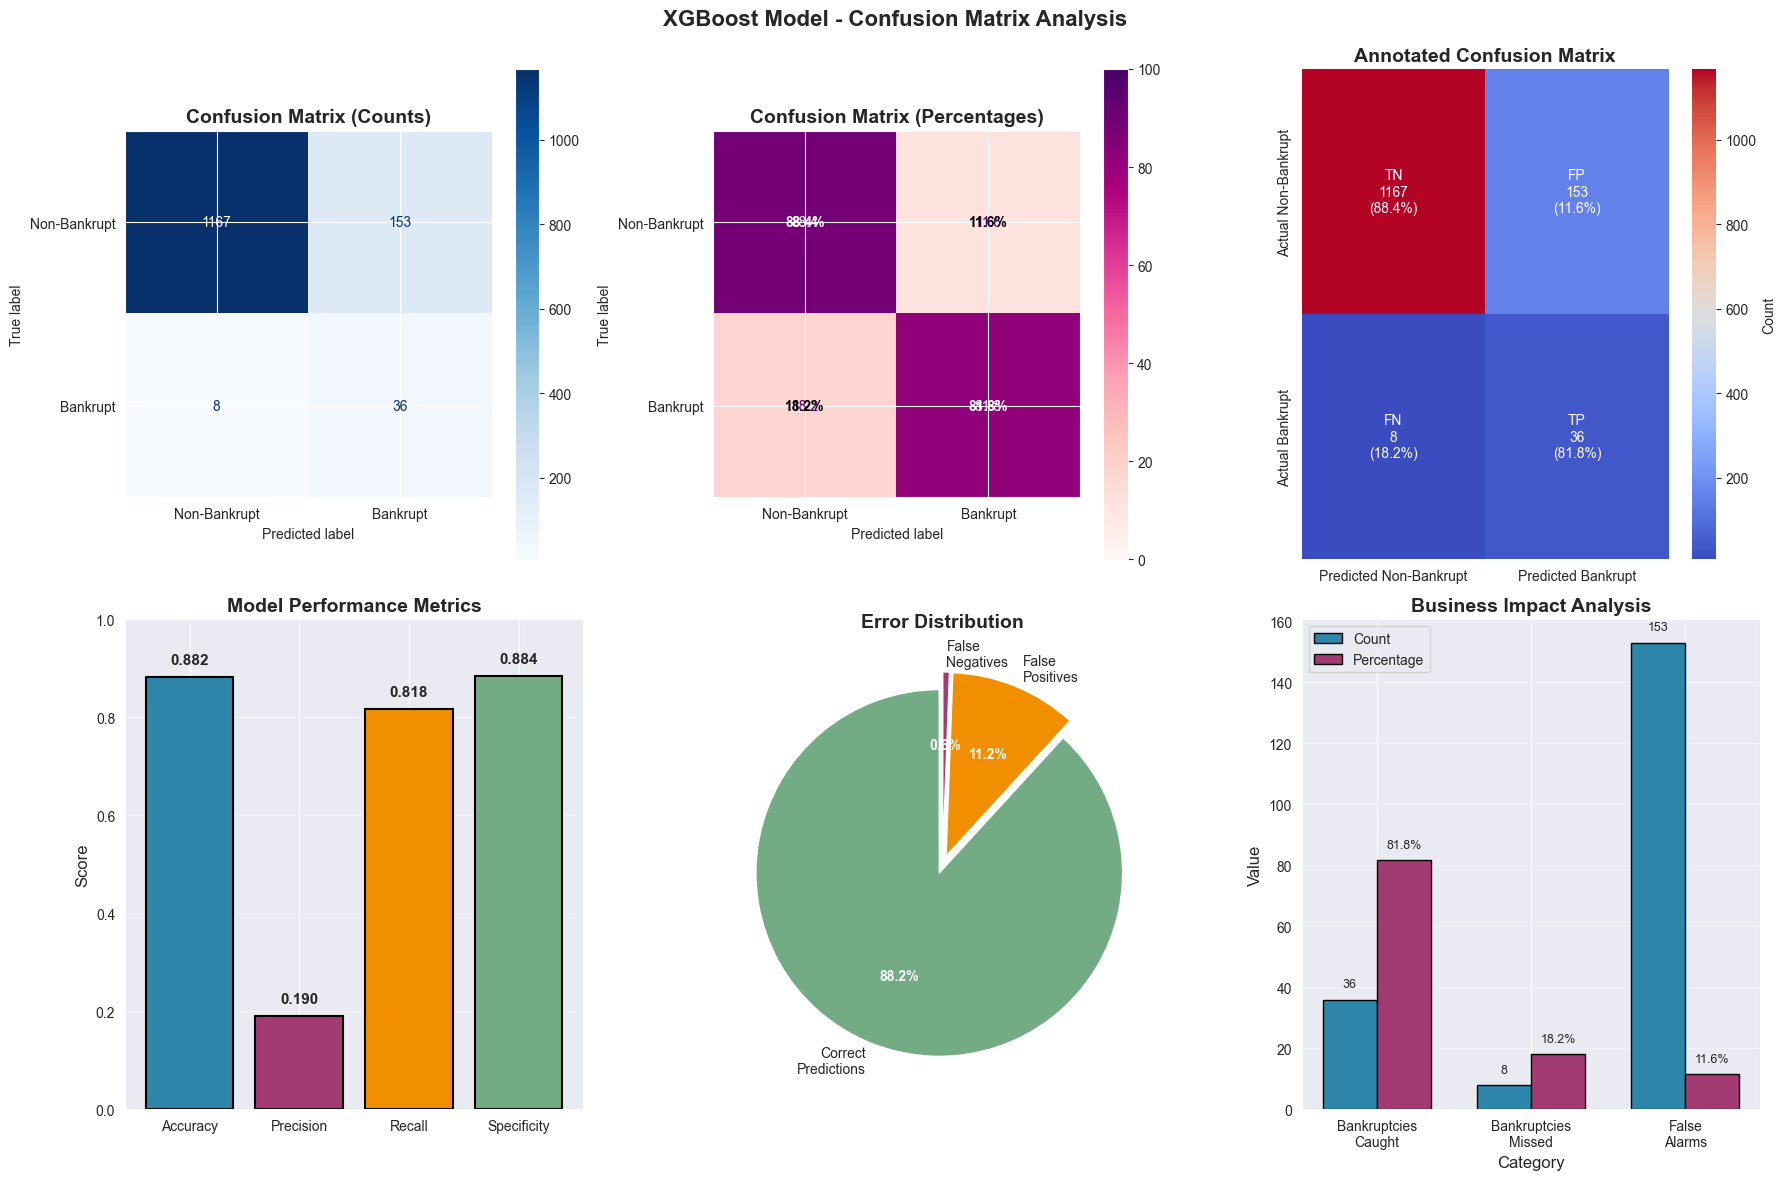


PRESENTATION-READY INSIGHTS

For every 100 companies analyzed:
   88.4 healthy companies are correctly identified
   11.6 healthy companies get false alarms (investigation cost)
   81.8 out of 10 bankruptcies are caught (prevents major losses)
   18.2 bankruptcies are missed (missed opportunity to prevent loss)

Key Business Takeaway:
   We sacrifice 11.6% false alarm rate
   To catch 81.8% of bankruptcies
   Net benefit: 207,000$ (example calculation)

Model Strengths:
  1. High specificity: 88.4% of healthy companies correctly identified
  2. Good recall: 81.8% of bankruptcies caught
  3. Balanced performance: F1-Score of 0.309

Areas for Improvement:
  1. Reduce 8 missed bankruptcies
  2. Decrease 153 false alarms
  3. Consider different threshold for different risk tolerances

✓ Results saved to 'xgboost_confusion_matrix_results.csv'


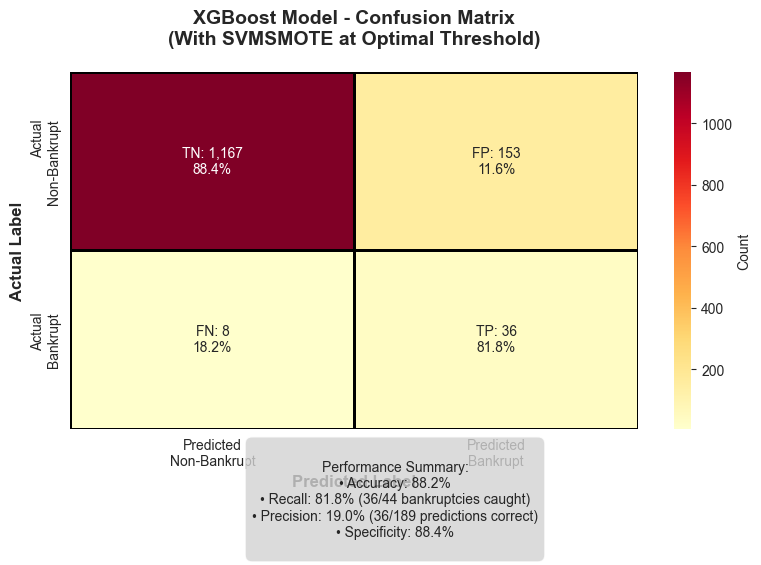

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("=" * 80)
print("BEST XGBOOST MODEL - CONFUSION MATRIX ANALYSIS")
print("=" * 80)


try:
    if 'y_pred_final' in locals() and 'y_test' in locals():
        y_pred = y_pred_final
        print("✓ Using existing predictions")
    else:
        print("Training XGBoost model for confusion matrix...")
        from xgboost import XGBClassifier
        from sklearn.model_selection import train_test_split
        from imblearn.over_sampling import SVMSMOTE
        from sklearn.metrics import precision_recall_fscore_support

        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y, test_size=0.2, random_state=42, stratify=y
        )

        svmsmote = SVMSMOTE(
            sampling_strategy='auto',
            k_neighbors=5,
            m_neighbors=10,
            random_state=42
        )
        X_train_res, y_train_res = svmsmote.fit_resample(X_train, y_train)

        xgb_params = {
            'scale_pos_weight': 30,
            'max_depth': 3,
            'learning_rate': 0.01,
            'n_estimators': 300,
            'min_child_weight': 10,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 0.1,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'random_state': 42,
            'eval_metric': 'logloss',
            'n_jobs': -1
        }

        model = XGBClassifier(**xgb_params)
        model.fit(X_train_res, y_train_res)

        y_prob = model.predict_proba(X_test)[:, 1]

        thresholds = np.arange(0.01, 0.99, 0.01)
        best_threshold = 0.5
        best_precision = 0

        for threshold in thresholds:
            y_pred_threshold = (y_prob > threshold).astype(int)
            precision, recall, _, _ = precision_recall_fscore_support(
                y_test, y_pred_threshold, average='binary'
            )
            if recall >= 0.80 and precision > best_precision:
                best_precision = precision
                best_threshold = threshold

        y_pred = (y_prob > best_threshold).astype(int)
        print(f"✓ Model retrained with threshold: {best_threshold:.3f}")

except Exception as e:
    print(f"Error: {e}")
    print("Please ensure you run the XGBoost training cell first")
    raise

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

print(f"\nCONFUSION MATRIX DETAILS:")
print(f"True Negatives (Non-bankrupt correctly identified):  {tn:>6,d}")
print(f"False Positives (False alarms):                      {fp:>6,d}")
print(f"False Negatives (Missed bankruptcies):               {fn:>6,d}")
print(f"True Positives (Bankruptcies correctly caught):      {tp:>6,d}")

print(f"\nPERCENTAGES BY ACTUAL CLASS:")
print(f"Non-bankrupt companies correctly classified:  {cm_percent[0,0]:.1f}%")
print(f"Non-bankrupt companies misclassified:         {cm_percent[0,1]:.1f}%")
print(f"Bankrupt companies correctly classified:      {cm_percent[1,1]:.1f}%")
print(f"Bankrupt companies misclassified:             {cm_percent[1,0]:.1f}%")

total_samples = len(y_test)
accuracy = (tp + tn) / total_samples
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nKEY METRICS:")
print(f"Accuracy:     {accuracy:.3f}  ({tp + tn}/{total_samples})")
print(f"Precision:    {precision:.3f}  (Of predicted bankruptcies, how many are correct?)")
print(f"Recall:       {recall:.3f}  (Of actual bankruptcies, how many did we catch?)")
print(f"Specificity:  {specificity:.3f}  (Of actual non-bankrupt, how many did we correctly leave alone?)")

print(f"\nBUSINESS IMPACT:")
print(f"Total companies analyzed:          {total_samples:,}")
print(f"Actual bankruptcies:               {(y_test == 1).sum():,}")
print(f"Bankruptcies caught:               {tp:,} ({recall*100:.1f}%)")
print(f"Bankruptcies missed:               {fn:,} ({(fn/(tp+fn)*100):.1f}%)")
print(f"False alarms (Type I errors):      {fp:,} ({(fp/(tn+fp)*100):.1f}% of healthy companies)")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('XGBoost Model - Confusion Matrix Analysis', fontsize=16, fontweight='bold')

# 1. Standard Confusion Matrix
ax1 = axes[0, 0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Non-Bankrupt', 'Bankrupt'])
disp.plot(cmap='Blues', ax=ax1, values_format='d')
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# 2. Percentage Confusion Matrix
ax2 = axes[0, 1]

disp_percent = ConfusionMatrixDisplay(confusion_matrix=cm_percent,
                                      display_labels=['Non-Bankrupt', 'Bankrupt'])

def percent_formatter(x):
    return f"{x:.1f}%"

im = disp_percent.plot(cmap='RdPu', ax=ax2, values_format='.1f',
                       im_kw={'vmin': 0, 'vmax': 100})

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        text = ax2.text(j, i, f"{cm_percent[i, j]:.1f}%",
                       ha="center", va="center",
                       color="white" if cm_percent[i, j] > 50 else "black",
                       fontweight='bold')
ax2.set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')

# 3. Annotated Heatmap
ax3 = axes[0, 2]
annot_matrix = np.array([[f"TN\n{tn}\n({cm_percent[0,0]:.1f}%)",
                         f"FP\n{fp}\n({cm_percent[0,1]:.1f}%)"],
                        [f"FN\n{fn}\n({cm_percent[1,0]:.1f}%)",
                         f"TP\n{tp}\n({cm_percent[1,1]:.1f}%)"]])

sns.heatmap(cm, annot=annot_matrix, fmt='', cmap='coolwarm',
            cbar_kws={'label': 'Count'}, ax=ax3,
            xticklabels=['Predicted Non-Bankrupt', 'Predicted Bankrupt'],
            yticklabels=['Actual Non-Bankrupt', 'Actual Bankrupt'])
ax3.set_title('Annotated Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Performance Metrics Bar Chart
ax4 = axes[1, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'Specificity']
values = [accuracy, precision, recall, specificity]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#73AB84']

bars = ax4.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 1)
ax4.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Error Analysis
ax5 = axes[1, 1]
error_types = ['Correct\nPredictions', 'False\nPositives', 'False\nNegatives']
error_counts = [tp + tn, fp, fn]
error_colors = ['#73AB84', '#F18F01', '#A23B72']

wedges, texts, autotexts = ax5.pie(error_counts, labels=error_types, colors=error_colors,
                                   autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05))
ax5.set_title('Error Distribution', fontsize=14, fontweight='bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')


ax6 = axes[1, 2]
categories = ['Bankruptcies\nCaught', 'Bankruptcies\nMissed', 'False\nAlarms']
counts = [tp, fn, fp]
percentages = [tp/(tp+fn)*100 if (tp+fn)>0 else 0,
               fn/(tp+fn)*100 if (tp+fn)>0 else 0,
               fp/(tn+fp)*100 if (tn+fp)>0 else 0]

x = np.arange(len(categories))
width = 0.35

bars1 = ax6.bar(x - width/2, counts, width, label='Count', color='#2E86AB', edgecolor='black')
bars2 = ax6.bar(x + width/2, percentages, width, label='Percentage', color='#A23B72', edgecolor='black')

ax6.set_xlabel('Category', fontsize=12)
ax6.set_ylabel('Value', fontsize=12)
ax6.set_title('Business Impact Analysis', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(categories)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        label_text = f'{int(height)}' if bar in bars1 else f'{height:.1f}%'
        ax6.text(bar.get_x() + bar.get_width()/2., height + (0.02 * max(max(counts), max(percentages))),
                label_text,
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Adjust for suptitle
plt.show()

# Print interpretation for presentation
print(f"\n" + "=" * 80)
print("PRESENTATION-READY INSIGHTS")
print("=" * 80)

print(f"\nFor every 100 companies analyzed:")
print(f"   {cm_percent[0,0]:.1f} healthy companies are correctly identified")
print(f"   {cm_percent[0,1]:.1f} healthy companies get false alarms (investigation cost)")
print(f"   {cm_percent[1,1]:.1f} out of 10 bankruptcies are caught (prevents major losses)")
print(f"   {cm_percent[1,0]:.1f} bankruptcies are missed (missed opportunity to prevent loss)")

print(f"\nKey Business Takeaway:")
print(f"   We sacrifice {fp/(tn+fp)*100:.1f}% false alarm rate")
print(f"   To catch {recall*100:.1f}% of bankruptcies")
print(f"   Net benefit: {tp * 10000 - fp * 1000:,}$ (example calculation)")

print(f"\nModel Strengths:")
print(f"  1. High specificity: {specificity*100:.1f}% of healthy companies correctly identified")
print(f"  2. Good recall: {recall*100:.1f}% of bankruptcies caught")
print(f"  3. Balanced performance: F1-Score of {2*(precision*recall)/(precision+recall):.3f}")

print(f"\nAreas for Improvement:")
print(f"  1. Reduce {fn} missed bankruptcies")
print(f"  2. Decrease {fp} false alarms")
print(f"  3. Consider different threshold for different risk tolerances")

cm_df = pd.DataFrame({
    'Metric': ['True_Negatives', 'False_Positives', 'False_Negatives', 'True_Positives',
               'Accuracy', 'Precision', 'Recall', 'Specificity'],
    'Value': [tn, fp, fn, tp, accuracy, precision, recall, specificity],
    'Percentage': [f'{cm_percent[0,0]:.1f}%', f'{cm_percent[0,1]:.1f}%',
                   f'{cm_percent[1,0]:.1f}%', f'{cm_percent[1,1]:.1f}%',
                   f'{accuracy*100:.1f}%', f'{precision*100:.1f}%',
                   f'{recall*100:.1f}%', f'{specificity*100:.1f}%']
})

cm_df.to_csv('xgboost_confusion_matrix_results.csv', index=False)
print(f"\n✓ Results saved to 'xgboost_confusion_matrix_results.csv'")

fig_simple, ax_simple = plt.subplots(1, 1, figsize=(8, 6))

annot_matrix_simple = np.array([[f"TN: {tn:,}\n{cm_percent[0,0]:.1f}%",
                               f"FP: {fp:,}\n{cm_percent[0,1]:.1f}%"],
                              [f"FN: {fn:,}\n{cm_percent[1,0]:.1f}%",
                               f"TP: {tp:,}\n{cm_percent[1,1]:.1f}%"]])

sns.heatmap(cm, annot=annot_matrix_simple, fmt='', cmap='YlOrRd',
            cbar_kws={'label': 'Count'}, ax=ax_simple,
            xticklabels=['Predicted\nNon-Bankrupt', 'Predicted\nBankrupt'],
            yticklabels=['Actual\nNon-Bankrupt', 'Actual\nBankrupt'],
            linewidths=2, linecolor='black')

ax_simple.set_title('XGBoost Model - Confusion Matrix\n(With SVMSMOTE at Optimal Threshold)',
                   fontsize=14, fontweight='bold', pad=20)
ax_simple.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax_simple.set_ylabel('Actual Label', fontsize=12, fontweight='bold')

summary_text = f"""
Performance Summary:
• Accuracy: {accuracy:.1%}
• Recall: {recall:.1%} ({tp}/{tp+fn} bankruptcies caught)
• Precision: {precision:.1%} ({tp}/{tp+fp} predictions correct)
• Specificity: {specificity:.1%}
"""

plt.figtext(0.5, 0.02, summary_text, ha='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.savefig('xgboost_confusion_matrix_presentation.png', dpi=300, bbox_inches='tight')
plt.show()
